# 5.1 a tidy forecasting workflow

In [87]:
import pandas as pd

# gdp_df = pd.read_csv("../data/tsibbledata/global_economy.csv")


gdp_df = (
    pd.read_csv("../data/tsibbledata/global_economy.csv")
    .assign(
        unique_id=lambda x: x["Country"],
        ds=lambda x: pd.to_datetime(x["Year"], format="%Y")
    )
    [["unique_id", "ds", "GDP", "Population"]]
    .assign(
        GDP=lambda x: x["GDP"].interpolate(),
        Population=lambda x: x["Population"].interpolate(),
        y=lambda x: x["GDP"] / x["Population"]
    )
)
gdp_df

,unique_id,ds,GDP,Population,y
0,Afghanistan,1960-01-01,5.377778e+08,8996351.0,59.777327
1,Afghanistan,1961-01-01,5.488889e+08,9166764.0,59.878153
2,Afghanistan,1962-01-01,5.466667e+08,9345868.0,58.492874
3,Afghanistan,1963-01-01,7.511112e+08,9533954.0,78.782758
4,Afghanistan,1964-01-01,8.000000e+08,9731361.0,82.208444
...,...,...,...,...,...
15145,Zimbabwe,2013-01-01,1.909102e+10,15054506.0,1268.126633
15146,Zimbabwe,2014-01-01,1.949552e+10,15411675.0,1264.983826
15147,Zimbabwe,2015-01-01,1.996312e+10,15777451.0,1265.294413
15148,Zimbabwe,2016-01-01,2.054868e+10,16150362.0,1272.335450


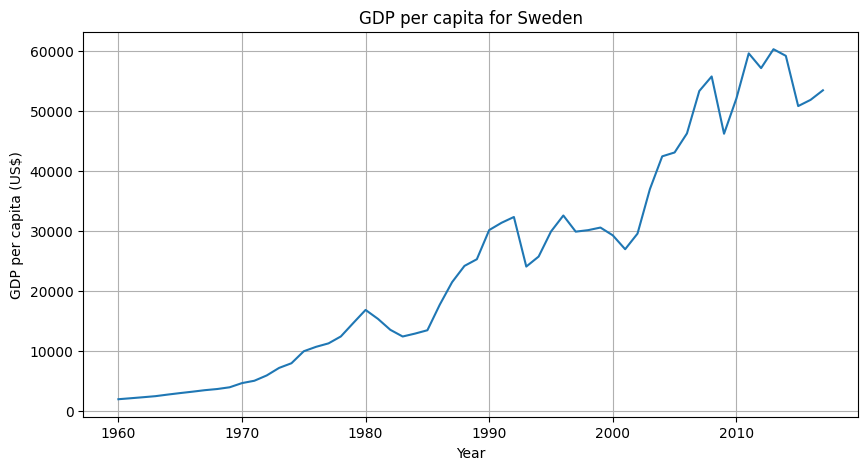

In [88]:
import matplotlib.pyplot as plt

sweden = gdp_df[gdp_df["unique_id"] == "Sweden"]

plt.figure(figsize=(10, 5))
plt.plot(sweden["ds"], sweden["y"])
plt.title("GDP per capita for Sweden")
plt.xlabel("Year")
plt.ylabel("GDP per capita (US$)")
plt.grid(True)
plt.show()

In [89]:
from utilsforecast.feature_engineering import pipeline, trend
from statsforecast import StatsForecast
from statsforecast.models import SklearnModel
from sklearn.linear_model import LinearRegression

sweden_df = (
    gdp_df.loc[lambda x: x["unique_id"] == "Sweden"]
    [["unique_id", "ds", "y"]]
)

train_features, valid_features = pipeline(
    sweden_df, features=[trend], freq="YS", h=3)

trend_model = SklearnModel(LinearRegression())

sf = StatsForecast(models=[trend_model], freq="YS")
sf.fit(df=train_features)

StatsForecast(models=[LinearRegression])

In [90]:
fcasts = sf.predict(h=3, X_df=valid_features)

fcasts

,unique_id,ds,LinearRegression
0,Sweden,2018-01-01,56165.505606
1,Sweden,2019-01-01,57225.849357
2,Sweden,2020-01-01,58286.193107


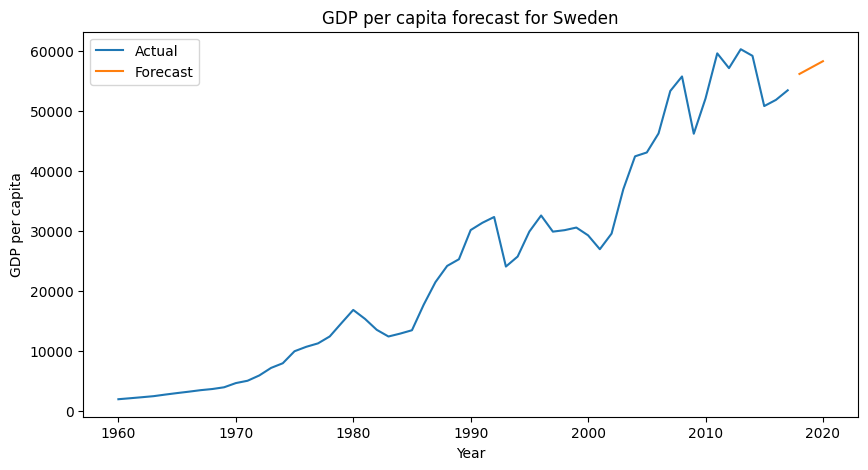

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sweden_df["ds"], sweden_df["y"], label="Actual")
plt.plot(fcasts["ds"], fcasts["LinearRegression"], label="Forecast")

plt.title("GDP per capita forecast for Sweden")
plt.xlabel("Year")
plt.ylabel("GDP per capita")
plt.legend()
plt.show()

Normally, we test the model on a holdout set first. If it performs well, then we train on the whole dataset and forecast the future.

# 5.2 some simple forecasting methods

## Average method

The forecasts of all future values are equal to the average (or “mean”) of the historical data.

In [92]:
production_df = pd.read_csv("../data/tsibbledata/aus_production.csv")

production_df["ds"] = pd.PeriodIndex(
    production_df["Quarter"].str.replace(" ", "", regex=False),
    freq="Q"
).to_timestamp()

bricks_df = (
    production_df
    .assign(
        unique_id="Bricks",
        y=production_df["Bricks"]
    )
    .loc[lambda x: x["ds"].between("1970-01-01", "2004-12-31")]
    [["unique_id", "ds", "y"]]
    .dropna()
)

bricks_df

,unique_id,ds,y
56,Bricks,1970-01-01,386.0
57,Bricks,1970-04-01,428.0
58,Bricks,1970-07-01,434.0
59,Bricks,1970-10-01,417.0
60,Bricks,1971-01-01,385.0
...,...,...,...
191,Bricks,2003-10-01,413.0
192,Bricks,2004-01-01,409.0
193,Bricks,2004-04-01,423.0
194,Bricks,2004-07-01,428.0


In [93]:
from statsforecast.models import HistoricAverage

avg_method = HistoricAverage()

sf = StatsForecast(models=[avg_method], freq="QS")

sf.fit(bricks_df)

forecasts = sf.predict(h=20)

forecasts.head()

,unique_id,ds,HistoricAverage
0,Bricks,2005-01-01,450.878571
1,Bricks,2005-04-01,450.878571
2,Bricks,2005-07-01,450.878571
3,Bricks,2005-10-01,450.878571
4,Bricks,2006-01-01,450.878571


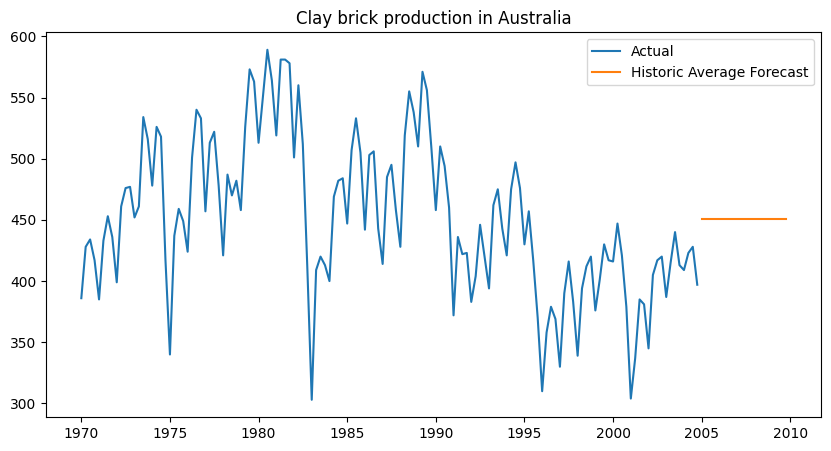

In [94]:
fig, ax = plt.subplots(figsize=(10, 5))

# Actual data
ax.plot(
    bricks_df["ds"],
    bricks_df["y"],
    label="Actual"
)

# Forecasts
ax.plot(
    forecasts["ds"],
    forecasts["HistoricAverage"],
    label="Historic Average Forecast"
)

ax.legend()
ax.set_title("Clay brick production in Australia")
plt.show()

## Naïve method



For naïve forecasts, we simply set all forecasts to be the value of the last observation

## Seasonal naïve method

A similar method is useful for highly seasonal data. In this case, we set each forecast to be equal to the last observed value from the same season 

## Drift method

A variation on the Naïve method is to allow the forecasts to increase or decrease over time, where the amount of change over time (called the drift) is set to be the average change seen in the historical data.

## Example: Australian quarterly beer production

In [95]:
beers_df = (
    production_df[["ds", "Beer"]]
    .rename(columns={"Beer": "y"})
    .assign(unique_id="Beer")
    [["unique_id", "ds", "y"]]
    .dropna()
)

beers_df["ds"] = pd.to_datetime(beers_df["ds"])

beers_df

,unique_id,ds,y
0,Beer,1956-01-01,284
1,Beer,1956-04-01,213
2,Beer,1956-07-01,227
3,Beer,1956-10-01,308
4,Beer,1957-01-01,262
...,...,...,...
213,Beer,2009-04-01,398
214,Beer,2009-07-01,419
215,Beer,2009-10-01,488
216,Beer,2010-01-01,414


In [96]:
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive


train = beers_df.loc[lambda x: (x["ds"] >= "1992-01-01") & (x["ds"] < "2007-01-01")]
test = beers_df.loc[lambda x: x["ds"] >= "2007-01-01"]

avg_method = HistoricAverage()
naive_method = Naive()
seasonal_naive_method = SeasonalNaive(season_length=4)

sf = StatsForecast(
    models=[avg_method, naive_method, seasonal_naive_method],
    freq="QS"
)

sf.fit(train)

fcasts = sf.predict(h=len(test))
fcasts = fcasts.assign(y=test["y"].to_numpy())

In [97]:
fcasts

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,y
0,Beer,2007-01-01,436.450012,491.0,438.0,427
1,Beer,2007-04-01,436.450012,491.0,386.0,383
2,Beer,2007-07-01,436.450012,491.0,405.0,394
3,Beer,2007-10-01,436.450012,491.0,491.0,473
4,Beer,2008-01-01,436.450012,491.0,438.0,420
5,Beer,2008-04-01,436.450012,491.0,386.0,390
6,Beer,2008-07-01,436.450012,491.0,405.0,410
7,Beer,2008-10-01,436.450012,491.0,491.0,488
8,Beer,2009-01-01,436.450012,491.0,438.0,415
9,Beer,2009-04-01,436.450012,491.0,386.0,398


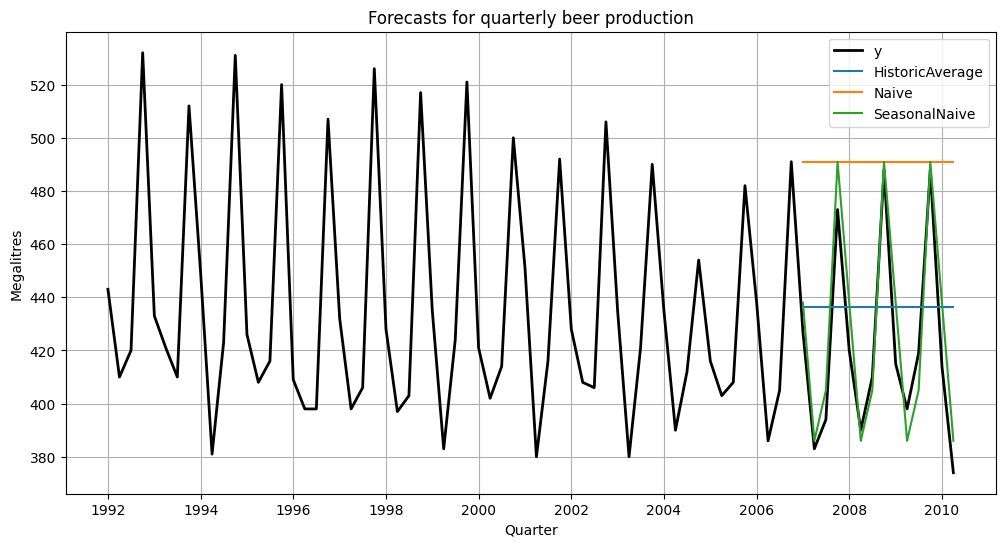

In [98]:
actual_all = pd.concat([train, test])

plt.figure(figsize=(12, 6))

plt.plot(actual_all["ds"], actual_all["y"], label="y", color="black", linewidth=2)

plt.plot(fcasts["ds"], fcasts["HistoricAverage"], label="HistoricAverage")
plt.plot(fcasts["ds"], fcasts["Naive"], label="Naive")
plt.plot(fcasts["ds"], fcasts["SeasonalNaive"], label="SeasonalNaive")

plt.title("Forecasts for quarterly beer production")
plt.xlabel("Quarter")
plt.ylabel("Megalitres")
plt.legend()
plt.grid(True)
plt.show()

## Example: Google’s daily closing stock price

In [99]:
goog_df = (
    pd.read_csv("../data/tsibbledata/gafa_stock.csv", parse_dates=["Date"])
    .loc[lambda x: (x["Symbol"] == "GOOG") & x["Date"].between("2015-01-01", "2016-01-31")]
    .rename(columns={"Date": "ds", "Close": "y"})
    .assign(unique_id="GOOG_Close")
    [["unique_id", "ds", "y"]]
)

In [104]:
import numpy as np
from statsforecast.models import RandomWalkWithDrift

train = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()

train["ds"] = np.arange(len(train))
test["ds"] = len(train) + np.arange(len(test))

avg_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()

sf = StatsForecast(
    freq=1,
    models=[drift_method, avg_method, naive_method]
)

sf.fit(train)

fcasts = sf.predict(h=len(test)).assign(y=test["y"].to_numpy())

fcasts.head()

,unique_id,ds,RWD,HistoricAverage,Naive,y
0,GOOG_Close,252,759.823998,601.550547,758.880005,741.840027
1,GOOG_Close,253,760.767991,601.550547,758.880005,742.580017
2,GOOG_Close,254,761.711984,601.550547,758.880005,743.619995
3,GOOG_Close,255,762.655977,601.550547,758.880005,726.390015
4,GOOG_Close,256,763.599970,601.550547,758.880005,714.469971


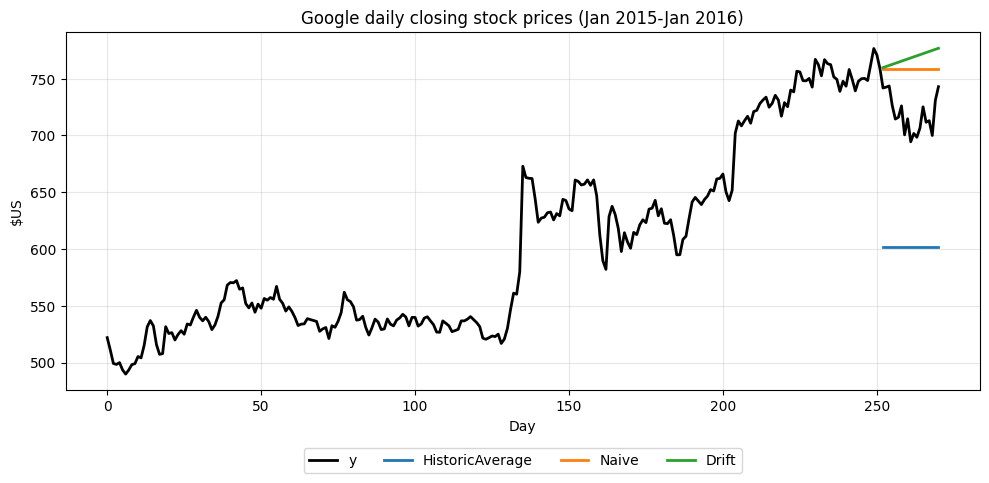

In [103]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine train and test actuals
actuals = pd.concat([train, test])

plt.figure(figsize=(10, 5))

# Actual values (black line)
plt.plot(
    actuals["ds"],
    actuals["y"],
    color="black",
    linewidth=2,
    label="y"
)

# Forecasts
plt.plot(
    fcasts["ds"],
    fcasts["HistoricAverage"],
    label="HistoricAverage",
    linewidth=2
)

plt.plot(
    fcasts["ds"],
    fcasts["Naive"],
    label="Naive",
    linewidth=2
)

plt.plot(
    fcasts["ds"],
    fcasts["RWD"],
    label="Drift",
    linewidth=2
)

plt.title("Google daily closing stock prices (Jan 2015-Jan 2016)")
plt.xlabel("Day")
plt.ylabel("$US")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5.3 Fitted values and residuals

a forecasting model produces fitted values. the difference between actual values and fitted values is called residual. Residuals are used to evalute whether a model has adequetly captured the patterns in the data.

fitted values are the predictions generated by the model for the training data -  the values are forecasted on the test data are called forecasts

In [134]:
beers_df = beers_df.loc[
    lambda x: (x["unique_id"] == "Beer") & (x["ds"] >= "1992")
]

train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]

avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="QS")
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
df = train.assign(
    fitted=fitted_values["HistoricAverage"].to_numpy(),
    resid=lambda x: x["y"] - x["fitted"],
    innov=lambda x: x["y"] - x["fitted"],
)

df.head()

,unique_id,ds,y,fitted,resid,innov
144,Beer,1992-01-01,443,436.450012,6.549988,6.549988
145,Beer,1992-04-01,410,436.450012,-26.450012,-26.450012
146,Beer,1992-07-01,420,436.450012,-16.450012,-16.450012
147,Beer,1992-10-01,532,436.450012,95.549988,95.549988
148,Beer,1993-01-01,433,436.450012,-3.450012,-3.450012


# 5.4 Residuals diagnotistics